# Vocabulary Level Prediction — RoBERTa comparison

Fine-tune `roberta-base` on **one consensus target** (`target_vocab` = mean of raters, same as `Model_selection`). Development split on filtered train; final fit on **full** train; evaluation on **test**. **Weighted MSE** on train matches rare-class emphasis from classical CV.

## 0. Environment

In [ ]:
import importlib
# !pip install Optuna # For google colab

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments
from transformers.trainer_utils import BestRun

import modeling_utils
import transformers_utils
import utils
import optuna

importlib.reload(utils)
importlib.reload(modeling_utils)
importlib.reload(transformers_utils)

from modeling_utils import (
    filter_by_rater_agreement,
    create_consensus_target,
    build_text_target_dataset,
    build_stratification_bins,
    evaluate_fold,
    round_and_clip_predictions,
    plot_ordinal_predicted_vs_true_scatter,
    plot_ordinal_continuous_boxplot_by_true_class,
    plot_row_normalized_confusion_matrix_from_labels,
)
from transformers_utils import (
    WeightedRegressionTrainer,
    build_compute_objective_fn,
    build_hf_regression_compute_metrics_fn,
    build_model_init_fn,
    build_optuna_hp_space_fn,
    build_tokenized_regression_dataset,
    build_weighted_regression_data_collator,
    get_completed_optuna_trial_count,
    prepare_balanced_regression_weights,
    suppress_hf_loading_report,
)

pd.set_option("display.max_colwidth", None)

## 1. Load data

`Data/train.csv`, `Data/test.csv` (same 80/20 split as EDA).

In [ ]:
df_train_raw = pd.read_csv("Data/train.csv")
df_test_raw = pd.read_csv("Data/test.csv")
print(f"Train rows: {len(df_train_raw)}  |  Test rows: {len(df_test_raw)}")

Train rows: 7112  |  Test rows: 1778


## 2. Preprocessing

**Train:** agreement filter + consensus `target_vocab` (same as model selection).  
**Test:** no agreement filter; consensus label for evaluation only (deployment-like).

### 2.1 Train: filter and consensus target

In [12]:
df_train = filter_by_rater_agreement(df_train_raw.copy())
df_train = create_consensus_target(df_train)
df_train_text = build_text_target_dataset(df_train)

### 2.2 Test: consensus label only (no row drops)

In [13]:
df_test_eval = create_consensus_target(df_test_raw.copy())
df_test_text = build_text_target_dataset(df_test_eval)

## 3. Targets and stratification bins

Single scalar target `y`; bins for **stratified** train/val split only (`merge_below=2` aligned with `Model_selection`).

In [14]:
RANDOM_STATE = 42
VAL_FRACTION = 0.15

text_train_all = df_train_text["Text_cleaned"].reset_index(drop=True)
y_train_all = np.asarray(df_train_text["target_vocab"].values, dtype=float)
stratification_bins = build_stratification_bins(y_train_all.astype(int), merge_below=2)

## 4. Train / validation split (development)

A 15% validation subset is held out for model selection and intermediate monitoring. Stratification is performed on merged ordinal bins to preserve low-frequency levels, and no test rows are used at this stage.

In [15]:
row_indices = np.arange(len(text_train_all))
idx_train, idx_val = train_test_split(
    row_indices,
    test_size=VAL_FRACTION,
    random_state=RANDOM_STATE,
    stratify=stratification_bins,
)

text_tr = text_train_all.iloc[idx_train].tolist()
text_val = text_train_all.iloc[idx_val].tolist()
y_tr = y_train_all[idx_train]
y_val = y_train_all[idx_val]

sample_weight_tr = prepare_balanced_regression_weights(y_tr.astype(int))
# Validation loss: uniform weights (interpretable MSE); collator still requires the column.
sample_weight_val = np.ones(len(idx_val), dtype=np.float64)

print(f"Train (dev): {len(text_tr)}  |  Val: {len(text_val)}")

Train (dev): 5783  |  Val: 1021


## 5. Model and tokenizer configuration

`roberta-base` is used with `AutoModelForSequenceClassification` configured as regression (`num_labels=1`, `problem_type="regression"`). This provides sequence-level regression fine-tuning from pretrained encoder weights.

In [16]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


### 5.1 Tokenized datasets

In [17]:
ds_train_dev = build_tokenized_regression_dataset(
    tokenizer, text_tr, y_tr, sample_weight_tr, MAX_LENGTH
)
ds_val = build_tokenized_regression_dataset(
    tokenizer, text_val, y_val, sample_weight_val, MAX_LENGTH
)

Map:   0%|          | 0/5783 [00:00<?, ? examples/s]

Map:   0%|          | 0/1021 [00:00<?, ? examples/s]

## 6. Phase A — Fine-tune on train (dev split)

`WeightedRegressionTrainer` is fit on the development-train subset with balanced sample weights. Validation QWK is evaluated each epoch, and the best checkpoint is selected by this metric.

In [19]:
with suppress_hf_loading_report():
    model_dev = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

training_args_dev = TrainingArguments(
    output_dir="./roberta_dev_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="qwk",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    report_to="none",
    # Keep labels + sample_weight for WeightedRegressionTrainer collator (default would drop non-forward keys).
    remove_unused_columns=False,
)

data_collator = build_weighted_regression_data_collator(tokenizer)
compute_metrics = build_hf_regression_compute_metrics_fn(min_score=0, max_score=5)

trainer_dev = WeightedRegressionTrainer(
    model=model_dev,
    args=training_args_dev,
    train_dataset=ds_train_dev,
    eval_dataset=ds_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_dev.train()
baseline_val_metrics = trainer_dev.evaluate(eval_dataset=ds_val)
baseline_val_qwk = float(baseline_val_metrics["eval_qwk"])
print(f"Baseline val QWK: {baseline_val_qwk:.4f}")

The following layers were not sharded: roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.LayerNorm.weight, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.LayerNorm.weight, classifier.out_proj.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.weight, classifier.dense.bias, roberta.encoder.layer.*.output.dense.weight, classifier.out_proj.weight, cl

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Qwk,Rmse,Mae
1,0.478412,0.468274,0.424282,0.684306,0.532942
2,0.387133,0.383784,0.597429,0.619503,0.482983
3,0.318872,0.423005,0.579925,0.650388,0.514296


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Baseline val QWK: 0.5963


## 7. Hyperparameter search (Optuna)

A constrained Optuna search is run for 15 trials to maximize validation QWK. Study state is persisted in SQLite (`optuna_roberta.db`) so interrupted runs are resumed from completed trials. Early stopping is applied through `MedianPruner` after epoch-level evaluations. The tuned configuration is accepted only if validation QWK exceeds the baseline value from 6; otherwise, baseline hyperparameters are retained.

In [20]:
N_TRIALS = 15
STUDY_NAME = "roberta_vocab_level"
OPTUNA_STORAGE = "sqlite:///optuna_roberta.db"

# Resume support: skip trials already persisted in the SQLite database.
completed_trials = get_completed_optuna_trial_count(OPTUNA_STORAGE, STUDY_NAME)
remaining_trials = max(0, N_TRIALS - completed_trials)

if completed_trials > 0:
    print(f"Resuming: {completed_trials} / {N_TRIALS} trials already done, {remaining_trials} remaining.")
else:
    print(f"Starting fresh: {N_TRIALS} trials.")

model_init = build_model_init_fn(MODEL_NAME, n_trials=N_TRIALS, suppress_load_report=True)
optuna_hp_space = build_optuna_hp_space_fn()
compute_objective = build_compute_objective_fn(metric_key="eval_qwk")

if remaining_trials > 0:
    # Trainer for HP search: model=None, model_init rebuilds a fresh model each trial.
    trainer_search = WeightedRegressionTrainer(
        model=None,
        model_init=model_init,
        args=training_args_dev,
        train_dataset=ds_train_dev,
        eval_dataset=ds_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    best_trial = trainer_search.hyperparameter_search(
        direction="maximize",
        backend="optuna",
        hp_space=optuna_hp_space,
        n_trials=remaining_trials,
        compute_objective=compute_objective,
        # kwargs forwarded to optuna.create_study for checkpoint / resume / pruning.
        storage=OPTUNA_STORAGE,
        study_name=STUDY_NAME,
        load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
    )
else:
    # All trials already done — load the study and reconstruct the BestRun.
    study = optuna.load_study(study_name=STUDY_NAME, storage=OPTUNA_STORAGE)
    bt = study.best_trial
    best_trial = BestRun(str(bt.number), bt.value, bt.params)

tuned_val_qwk = float(best_trial.objective)
print(f"\nBest tuned val QWK: {tuned_val_qwk:.4f}")
print(f"Best tuned hyperparameters: {best_trial.hyperparameters}")
print(f"Baseline val QWK (from §6): {baseline_val_qwk:.4f}")

if tuned_val_qwk > baseline_val_qwk:
    selected_hyperparameters = dict(best_trial.hyperparameters)
    selected_configuration_source = "optuna_tuned"
    print("Selected configuration: Optuna-tuned hyperparameters (better validation QWK).")
else:
    selected_hyperparameters = {
        "learning_rate": training_args_dev.learning_rate,
        "per_device_train_batch_size": training_args_dev.per_device_train_batch_size,
        "num_train_epochs": int(training_args_dev.num_train_epochs),
        "weight_decay": training_args_dev.weight_decay,
        "warmup_ratio": training_args_dev.warmup_ratio,
    }
    selected_configuration_source = "baseline"
    print("Selected configuration: Baseline hyperparameters (no validation QWK gain from tuning).")

print(f"Selected hyperparameters: {selected_hyperparameters}")

Starting fresh: 15 trials.


The following layers were not sharded: roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.LayerNorm.weight, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.LayerNorm.weight, classifier.out_proj.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.weight, classifier.dense.bias, roberta.encoder.layer.*.output.dense.weight, classifier.out_proj.weight, cl

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[I 2026-03-23 10:50:24,308] A new study created in RDB with name: roberta_vocab_level



  Trial 1 / 15


...

The following layers were not sharded: roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.LayerNorm.weight, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.LayerNorm.weight, classifier.out_proj.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.weight, classifier.dense.bias, roberta.encoder.layer.*.output.dense.weight, classifier.out_proj.weight, cl

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Qwk,Rmse,Mae
1,0.548561,0.420463,0.408009,0.648431,0.549998


[I 2026-03-23 12:54:50,339] Trial 14 pruned. 



Best tuned val QWK: 0.5681
Best tuned hyperparameters: {'learning_rate': 1.583344355759762e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 8, 'weight_decay': 0.055967728028410116, 'warmup_ratio': 0.054648803445469664}
Baseline val QWK (from §6): 0.5963
Selected configuration: Baseline hyperparameters (no validation QWK gain from tuning).
Selected hyperparameters: {'learning_rate': 3.1736625609180606e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 4, 'weight_decay': 0.05025046105947497, 'warmup_ratio': 0.1165940564196155}


A baseline end-to-end RoBERTa regression run was first trained with conservative, literature-standard fine-tuning defaults (small learning rate, moderate epochs, standard batch size and regularization) to provide a stable reference under limited data and compute. Optuna then searched alternative hyperparameters under the same train/dev split and validation QWK, so differences were attributable only to hyperparameter choice. Because the best tuned trial did not improve validation QWK, the baseline configuration was retained.

## 8. Phase B — Refit on full train (selected hparams)

The model is now refit from scratch on the entire agreement-filtered training set, with no development holdout, so all available supervised data are used for the final checkpoint that is evaluated on test.

In [22]:
sample_weight_full = prepare_balanced_regression_weights(y_train_all.astype(int))
text_full = text_train_all.tolist()
ds_train_full = build_tokenized_regression_dataset(
    tokenizer, text_full, y_train_all, sample_weight_full, MAX_LENGTH
)

with suppress_hf_loading_report():
    model_full = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="regression",
    )

# Refit uses the configuration selected in §7 (tuned only if it improved val QWK).
selected_hp = selected_hyperparameters
print(f"Refit configuration source: {selected_configuration_source}")
training_args_full = TrainingArguments(
    output_dir="./roberta_full_output",
    learning_rate=selected_hp["learning_rate"],
    per_device_train_batch_size=selected_hp["per_device_train_batch_size"],
    num_train_epochs=selected_hp["num_train_epochs"],
    weight_decay=selected_hp["weight_decay"],
    warmup_ratio=selected_hp["warmup_ratio"],
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=50,
    seed=RANDOM_STATE,
    fp16=torch.cuda.is_available(),
    report_to="none",
    remove_unused_columns=False,
)

trainer_full = WeightedRegressionTrainer(
    model=model_full,
    args=training_args_full,
    train_dataset=ds_train_full,
    processing_class=tokenizer,
    data_collator=data_collator,
)

trainer_full.train()

Map:   0%|          | 0/6804 [00:00<?, ? examples/s]

The following layers were not sharded: roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.LayerNorm.weight, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.output.dense.bias, roberta.encoder.layer.*.intermediate.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.self.query.weight, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.output.LayerNorm.weight, classifier.out_proj.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.encoder.layer.*.intermediate.dense.weight, classifier.dense.bias, roberta.encoder.layer.*.output.dense.weight, classifier.out_proj.weight, cl

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Refit configuration source: baseline


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1704, training_loss=0.6791641729328554, metrics={'train_runtime': 816.4758, 'train_samples_per_second': 33.334, 'train_steps_per_second': 2.087, 'total_flos': 7160346858990816.0, 'train_loss': 0.6791641729328554, 'epoch': 4.0})

## 9. Test-set evaluation

Evaluation is performed only after final refit on training data. Predictions are generated on the untouched test split and summarized with QWK, RMSE, MAE, and ordinal diagnostics; no test information is used during model selection.

### 9.1 Predict on test

In [23]:
text_test = df_test_text["Text_cleaned"].reset_index(drop=True).tolist()
y_test = np.asarray(df_test_text["target_vocab"].values, dtype=int)
weights_test_dummy = np.ones(len(text_test), dtype=np.float32)

ds_test = build_tokenized_regression_dataset(
    tokenizer, text_test, y_test.astype(float), weights_test_dummy, MAX_LENGTH
)

pred_out = trainer_full.predict(ds_test)
y_pred_test = np.asarray(pred_out.predictions, dtype=float).squeeze()

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

### 9.2 Metrics (QWK, RMSE, MAE)

In [25]:
test_metrics = evaluate_fold(y_test, y_pred_test, min_score=0, max_score=5)
summary_test = (
    pd.DataFrame([test_metrics], index=["Test set (RoBERTa, tuned)"])
    .rename(columns={"qwk": "QWK", "rmse": "RMSE", "mae": "MAE"})
)
display(summary_test)

,QWK,RMSE,MAE
"Test set (RoBERTa, tuned)",0.564896,0.689487,0.52952


The three metrics exceeds TF-IDF + MLP, but not significantly.

### 9.3 Diagnostic plots

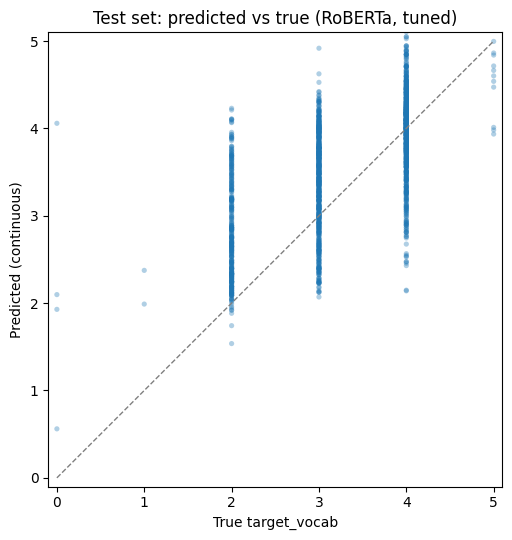

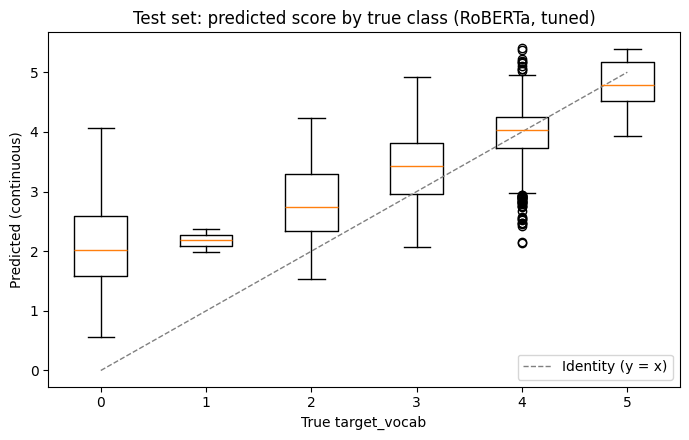

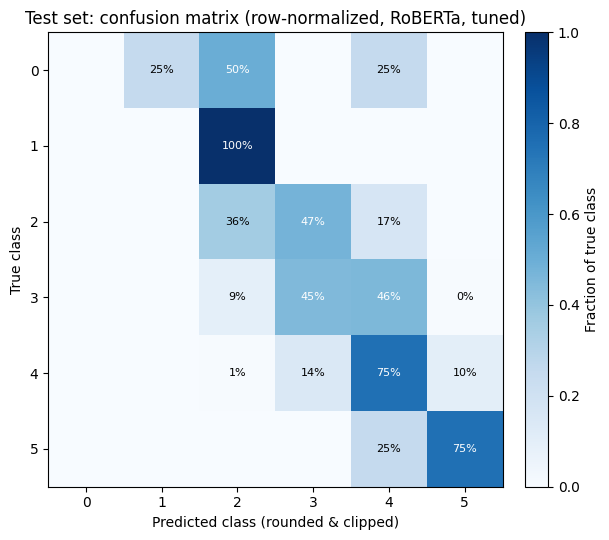

In [ ]:
fig_scatter = plot_ordinal_predicted_vs_true_scatter(
    y_test,
    y_pred_test,
    title="Test set: predicted vs true (RoBERTa, tuned)",
    xlabel="True target_vocab",
)
plt.show()

fig_box = plot_ordinal_continuous_boxplot_by_true_class(
    y_test,
    y_pred_test,
    title="Test set: predicted score by true class (RoBERTa, tuned)",
    xlabel="True target_vocab",
)
plt.show()

y_pred_ord = round_and_clip_predictions(y_pred_test, 0, 5)
ordinal_labels = np.arange(0, 6)
fig_cm = plot_row_normalized_confusion_matrix_from_labels(
    y_test,
    y_pred_ord,
    labels=ordinal_labels,
    title="Test set: confusion matrix (row-normalized, RoBERTa, tuned)",
    xlabel="Predicted class (rounded & clipped)",
)
plt.show()

RoBERTa predictions remain concentrated around adjacent levels, indicating mainly local (about +/-1) errors and preserved ordinal ranking. Relative to TF-IDF + MLP, mid-range behavior is broadly similar, but the upper end is clearer in RoBERTa: true classes 4 and 5 are identified more accurately, with a stronger diagonal at those levels (about 75% for both). Thus, overall boundary separation is still limited, yet high-level vocabulary recognition is improved in the transformer model.